### Langraph

In [3]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv()

c:\Users\Administrator\Downloads\b150-genaiops\18_Langchain\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

`InMemorySaver` is model-agnostic. It does not care whether you use Groq, Qwen, Llama, OpenAI, etc. It only stores the agent’s checkpoint/state in Python process memory so the agent can resume short-term conversation state when you invoke it with the same thread/config.

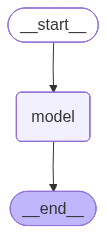

In [4]:
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # model="groq:qwen/qwen3-32b",
    # system_prompt="You are a helpful assistant.",
    checkpointer=InMemorySaver()
)
agent

In [5]:
## Making a thread with thread id , to maintain a session
config={"configurable":{"thread_id":"test1"}}

In [6]:
from langchain_core.messages import HumanMessage, SystemMessage
response=agent.invoke({"messages":[HumanMessage(content="Hi my name is rakesh")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is rakesh', additional_kwargs={}, response_metadata={}, id='8444a20f-dc48-4b56-ada5-1407d8e0014c'),
  AIMessage(content="Hello Rakesh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.050976232, 'completion_tokens_details': None, 'prompt_time': 0.003986116, 'prompt_tokens_details': None, 'queue_time': 0.037192435, 'total_time': 0.054962348}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d21-56a6-7d62-b2f6-8a75b9c2960c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70})]}

In [7]:
# will it remmber me, how will it maintain session id --> using same config
response=agent.invoke({"messages":[HumanMessage(content="what is my name?")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is rakesh', additional_kwargs={}, response_metadata={}, id='8444a20f-dc48-4b56-ada5-1407d8e0014c'),
  AIMessage(content="Hello Rakesh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.050976232, 'completion_tokens_details': None, 'prompt_time': 0.003986116, 'prompt_tokens_details': None, 'queue_time': 0.037192435, 'total_time': 0.054962348}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d21-56a6-7d62-b2f6-8a75b9c2960c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_

##### Another user

In [8]:
## Another users
config={"configurable":{"thread_id":"test2"}}
response=agent.invoke({"messages":[HumanMessage(content="Hi my name is John")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is John', additional_kwargs={}, response_metadata={}, id='e3d19062-f781-4a29-91a5-979e96426dc9'),
  AIMessage(content="Hello John, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 40, 'total_tokens': 66, 'completion_time': 0.056708886, 'completion_tokens_details': None, 'prompt_time': 0.008634244, 'prompt_tokens_details': None, 'queue_time': 0.1458924, 'total_time': 0.06534313}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d21-58e9-7b22-a672-313f9702f1c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 26, 'total_tokens': 66})]}

In [9]:
response=agent.invoke({"messages":[HumanMessage(content="what is my name?")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is John', additional_kwargs={}, response_metadata={}, id='e3d19062-f781-4a29-91a5-979e96426dc9'),
  AIMessage(content="Hello John, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 40, 'total_tokens': 66, 'completion_time': 0.056708886, 'completion_tokens_details': None, 'prompt_time': 0.008634244, 'prompt_tokens_details': None, 'queue_time': 0.1458924, 'total_time': 0.06534313}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d21-58e9-7b22-a672-313f9702f1c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 26, 'total_tokens': 66}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadat